# monogpt API KEY langchain 사용

# API Key 로딩

In [1]:
# .env
# LLM_API_KEY=your_api_key
# LLM_BASE_URL=https://monogpt.kr/api/monorouter/v1
# OLLAMA_BASE_URL=http://localhost:11434

In [2]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(override=True)

api_key = os.getenv("LLM_API_KEY")

BASE_URL = os.getenv("LLM_BASE_URL")

## OpenAI 모델

In [3]:
llm = ChatOpenAI(
    model="gpt-5.5",
    api_key=api_key,
    base_url=BASE_URL,
    use_responses_api=False,  # base url로 할 때는 이부분 넣어야 함.
    max_tokens=526
)

In [4]:
response = llm.invoke("파이썬 계산기 코드 작성해줘")

print(response.content)

아래는 간단한 **파이썬 콘솔 계산기 코드**입니다.

```python
def calculator():
    print("파이썬 계산기")
    print("사용 가능한 연산: +, -, *, /")
    print("종료하려면 q를 입력하세요.")

    while True:
        num1 = input("\n첫 번째 숫자를 입력하세요: ")

        if num1.lower() == "q":
            print("계산기를 종료합니다.")
            break

        operator = input("연산자를 입력하세요 (+, -, *, /): ")

        if operator.lower() == "q":
            print("계산기를 종료합니다.")
            break

        num2 = input("두 번째 숫자를 입력하세요: ")

        if num2.lower() == "q":
            print("계산기를 종료합니다.")
            break

        try:
            num1 = float(num1)
            num2 = float(num2)

            if operator == "+":
                result = num1 + num2
            elif operator == "-":
                result = num1 - num2
            elif operator == "*":
                result = num1 * num2
            elif operator == "/":
                if num2 == 0:
                    print("0으로 나눌 수 없습니다.")
                    continue
                re

In [5]:
from IPython.display import display, Markdown

display(Markdown(response.content))

아래는 간단한 **파이썬 콘솔 계산기 코드**입니다.

```python
def calculator():
    print("파이썬 계산기")
    print("사용 가능한 연산: +, -, *, /")
    print("종료하려면 q를 입력하세요.")

    while True:
        num1 = input("\n첫 번째 숫자를 입력하세요: ")

        if num1.lower() == "q":
            print("계산기를 종료합니다.")
            break

        operator = input("연산자를 입력하세요 (+, -, *, /): ")

        if operator.lower() == "q":
            print("계산기를 종료합니다.")
            break

        num2 = input("두 번째 숫자를 입력하세요: ")

        if num2.lower() == "q":
            print("계산기를 종료합니다.")
            break

        try:
            num1 = float(num1)
            num2 = float(num2)

            if operator == "+":
                result = num1 + num2
            elif operator == "-":
                result = num1 - num2
            elif operator == "*":
                result = num1 * num2
            elif operator == "/":
                if num2 == 0:
                    print("0으로 나눌 수 없습니다.")
                    continue
                result = num1 / num2
            else:
                print("올바른 연산자를 입력하세요.")
                continue

            print("결과:", result)

        except ValueError:
            print("숫자를 올바르게 입력하세요.")


calculator()
```

실행하면 예를 들어 다음처럼 사용할 수 있습니다.

```text
첫 번째 숫자를 입력하세요: 10
연산자를 입력하세요 (+, -, *, /): +
두 번째 숫자를 입력하세요: 5
결과: 15.0
```

## Claude 모델

In [6]:
# claude = ChatOpenAI(
#     model="claude-haiku-4.5",
#     api_key=api_key,
#     base_url=BASE_URL,
#     temperature=0,
#     max_tokens=512,
# )

claude = ChatOpenAI(
    model="claude-haiku-4.5",
    api_key=api_key,
    base_url=BASE_URL,
    use_responses_api=False,  # base url로 할 때는 이부분 넣어야 함.(MonoRouter 사용)
    max_tokens=526
)

```text
LangChain
   ↓
ChatOpenAI
   ↓
use_responses_api=False
   ↓
POST /chat/completions
   ↓
MonoRouter
   ↓
Gemini
```

In [7]:
response = claude.invoke(
    "LangGraph와 LangChain의 차이를 설명해줘"
)

print(response.content)

# LangGraph vs LangChain 비교

## 📊 핵심 차이점

| 항목 | LangChain | LangGraph |
|------|----------|-----------|
| **목적** | LLM 애플리케이션 개발 프레임워크 | 상태 관리형 에이전트 구축 |
| **주요 기능** | 프롬프트, 메모리, 체인 | 그래프 기반 워크플로우 |
| **상태 관리** | 제한적 | 명시적, 강력함 |
| **복잡도** | 낮음 | 높음 |
| **디버깅** | 어려움 | 시각화 지원 |

---

## 🔍 상세 설명

### **LangChain**
```python
from langchain.llms import OpenAI
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate

# 간단한 체인 구성
prompt = PromptTemplate(
    input_variables=["topic"],
    template="Write a short story about {topic}"
)

chain = LLMChain(llm=OpenAI(), prompt=prompt)
result = chain.run(topic="AI")
```

**특징:**
- ✅ LLM과 도구 통합 용이
- ✅ 프롬프트 템플릿, 메모리 관리
- ✅ 학습 곡선 완만
- ❌ 복잡한 상태 관리 어려움
- ❌ 조건부 분기 처리 복잡

---

### **LangGraph**
```python
from langgraph.graph import StateGraph
from langchain.llms import OpenAI
from typing import TypedDict

# 상태 정의
class AgentState(TypedDict):
    messages: list
    decision: str

# 그래프 구성


In [8]:
from langchain_core.messages import (
    SystemMessage,
    HumanMessage
)

messages = [
    SystemMessage(
        content="당신은 생성형 AI 전문 강사입니다."
    ),
    HumanMessage(
        content="Agentic RAG를 초보자에게 설명해줘."
    )
]

response = claude.invoke(messages)

display(Markdown(response.content))

# Agentic RAG 초보자 설명

## 1. 기본 개념부터 시작하기

### RAG란?
**R**etrieval-**A**ugmented **G**eneration의 약자로, AI가 답변할 때 **외부 문서를 참고**하는 기술입니다.

```
일반 AI: 질문 → 답변
RAG AI: 질문 → 문서 검색 → 참고해서 답변
```

### Agentic이란?
AI가 **스스로 판단하며 행동**한다는 뜻입니다.

```
일반 RAG: 정해진 순서대로만 검색 → 답변
Agentic RAG: AI가 "뭘 검색할지", "더 찾을지" 스스로 결정 → 답변
```

---

## 2. 실제 비유로 이해하기

**일반 RAG의 도서관 사서:**
- 고객: "낙타에 대해 알려줘"
- 사서: "낙타 책 3권 드립니다" (자동으로 정해진 책들을 줌)
- 사서: "답변 완료!"

**Agentic RAG의 도서관 사서:**
- 고객: "낙타에 대해 알려줘"
- 사서: "낙타 책을 찾아볼까? 아니면 동물학 백과사전도 필요할까?" (스스로 판단)
- 사서: "낙타 책 3권도 봤는데... 사막 환경 책도 필요하겠네?" (추가 검색)
- 사서: "이제 충분한 정보가 있으니 설명하겠습니다"

---

## 3. 핵심 차이점

## Gemini 모델

In [9]:
gemini = ChatOpenAI(
    model="gemini-3.5-flash",
    api_key=api_key,
    base_url=BASE_URL,
    temperature=0,
    use_responses_api=False,  # base url로 할 때는 이부분 넣어야 함.(MonoRouter 사용)
    max_tokens=2048,
    # max_tokens=512,
    reasoning_effort="minimal"
)

response = gemini.invoke("RAG를 설명해줘")

print(response.content)

**RAG(Retrieval-Augmented Generation, 검색 증강 생성)**는 거대 언어 모델(LLM)의 한계를 극복하기 위해 최근 인공지능 분야에서 가장 주목받고 있는 기술입니다.

쉽게 한 줄로 요약하자면, **"AI에게 오픈북 시험을 보게 하는 기술"**입니다.

RAG가 무엇인지, 왜 필요한지, 어떻게 작동하는지 알기 쉽게 설명해 드릴게요.

---

### 1. RAG가 필요한 이유 (기존 LLM의 한계)

ChatGPT 같은 거대 언어 모델은 똑똑하지만 몇 가지 치명적인 약점이 있습니다.

1. **환각 현상 (Hallucination):** 모르는 것도 마치 사실인 것처럼 그럴듯하게 거짓말을 합니다.
2. **최신 정보의 부재:** 모델이 학습을 마친 시점 이후의 최신 정보는 알지 못합니다.
3. **내부 데이터 보안:** 기업 내부 문서나 개인 정보는 학습되지 않았기 때문에 대답할 수 없습니다.

이 문제를 해결하기 위해 과거에는 AI를 처음부터 다시 학습시키거나(Fine-tuning), 프롬프트를 길게 작성해야 했습니다. 하지만 이는 비용이 너무 많이 들거나 한계가 있었습니다. **이때 등장한 해결책이 바로 RAG입니다.**

---

### 2. RAG의 핵심 개념: "오픈북 시험"

* **기존 LLM (암기 시험):** 머릿속에 저장된 지식(학습 데이터)만 가지고 답을 씁니다. 기억이 안 나면 소설을 씁니다.
* **RAG 적용 LLM (오픈북 시험):** 질문을 받으면, 먼저 관련 서적이나 데이터베이스(인터넷 검색, 회사 문서 등)에서 **관련 내용을 찾아본 뒤(Retrieval)**, 그 내용을 바탕으로 **정확한 답변을 작성(Generation)**합니다.

---

### 3. RAG의 작동 단계 (3단계)

사용자가 질문을 던졌을 때 RAG는 내부적으로 다음과 같이 작동합니다.

1. **검색 (Retrieval):**
   * 사용자가 "우리 회사 올해 휴가 규정 알려줘"라고 질문합니다.
   * RAG 시스템은 회

# GPT / Claude / Gemini를 하나의 함수로 처리

In [10]:
from langchain_openai import ChatOpenAI


def get_llm(
    model: str,
    temperature: float = 0,
    max_tokens: int = 512
):
    return ChatOpenAI(
        model=model,
        api_key=api_key,
        base_url=BASE_URL,
        temperature=temperature,
        use_responses_api=False,  # base url로 할 때는 이부분 넣어야 함.(MonoRouter 사용)
        max_tokens=max_tokens,
    )

## claude 모델

In [11]:
llm = get_llm("claude-haiku-4.5")

response = llm.invoke(
    "RAG란 무엇인가?"
)

print(response.content)

# RAG(Retrieval-Augmented Generation)란?

RAG는 **검색 기반 생성 기술**로, 대규모 언어모델(LLM)의 성능을 향상시키는 방식입니다.

## 기본 개념

```
사용자 질문 → 관련 정보 검색 → LLM에 전달 → 답변 생성
```

## 주요 특징

### 1. **두 가지 단계**
- **검색(Retrieval)**: 외부 데이터베이스에서 관련 정보 찾기
- **생성(Generation)**: 검색된 정보를 바탕으로 답변 생성

### 2. **장점**
- ✅ 최신 정보 활용 가능
- ✅ 할루시네이션(거짓 정보) 감소
- ✅ 특정 도메인 지식 활용
- ✅ 출처 제시 가능

## 실제 예시

**RAG 없이:**
- Q: "2024년 최신 뉴스는?"
- A: 학습 데이터 기준으로만 답변 (오래된 정보)

**RAG 적용:**
- Q: "2024년 최신 뉴스는?"
- A: 실시간 뉴스 DB 검색 → 최신 정보 제공

## 활용 분야
- 챗봇, 고객 지원
- 문서 기반 Q&A
- 법률/의료 정보 시스템

RAG는 LLM의 신뢰성과 정확성을 크게 향상시키는 중요한 기술입니다.


## GPT 모델

In [12]:
llm = get_llm("gpt-5.4")
response = llm.invoke(
    "RAG란 무엇인가?"
)

print(response.content)

RAG는 보통 **Retrieval-Augmented Generation**의 약자입니다. 한국어로는 **검색 증강 생성** 정도로 번역할 수 있습니다.

간단히 말하면:

- **LLM(대규모 언어 모델)** 이
- 자기 내부에만 저장된 지식으로 답하는 대신,
- **외부 문서, 데이터베이스, 사내 자료, 웹 검색 결과** 등을 먼저 찾아보고
- 그 내용을 바탕으로 답을 생성하는 방식입니다.

### 왜 필요한가?
일반 LLM은 다음 한계가 있습니다.

- 최신 정보를 모를 수 있음
- 특정 회사/조직의 내부 문서를 모름
- 사실이 아닌 내용을 그럴듯하게 말하는 **환각(hallucination)** 이 생길 수 있음

RAG는 이런 문제를 줄이기 위해 사용됩니다.

### 동작 방식
보통 다음 순서로 작동합니다.

1. 사용자가 질문함
2. 시스템이 관련 문서들을 검색함
3. 검색된 문서를 LLM에 함께 넣음
4. LLM이 그 근거를 바탕으로 답변 생성

예:
- 질문: “우리 회사 환불 정책이 뭐야?”
- 검색: 사내 정책 문서 찾기
- 생성: 해당 문서 내용을 바탕으로 답변

### 장점
- **최신 정보 반영 가능**
- **도메인 특화 지식 활용 가능**
- **답변 근거를 제시하기 쉬움**
- **모델 재학습 없이도 지식 확장 가능**

### 단점
- 검색이 잘못되면 답변도 부정확해질 수 있음
- 시스템 구성이 복잡해짐
- 문서 품질이 낮으면 성능이 떨어짐

### 어디에 쓰이나?
- 사내 문서 QA 챗봇
- 고객지원 봇
- 법률/의료/금융 정보 검색 보조
- 논문/매뉴얼 기반 질의응답

원하시면 다음으로  
**“RAG의 기술적 구조(임베딩, 벡터DB, 리랭킹 등)”** 까지 이어서 설명해드릴게요.


## Gemini 모델

In [13]:
gemini = get_llm("gemini-3.8-flash")
response = gemini.invoke(
    "RAG란 무엇인가?"
)

print(response.content)

vs. Fine-tuning):** Brief clarification, as people often confuse them.
    *


# PromptTemplate과 Claude 연결

In [14]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "당신은 AI 교육 전문 강사입니다."
    ),
    (
        "human",
        "{question}"
    )
])

claude = get_llm("claude-haiku-4.5")

chain = prompt | claude

In [15]:
response = chain.invoke({
    "question": "Naive RAG와 Agentic RAG의 차이를 설명해줘."
})

display(Markdown(response.content))

# Naive RAG vs Agentic RAG

## 📊 핵심 차이점

### **Naive RAG (기본 RAG)**
```
사용자 질문 → 문서 검색 → LLM 응답
```
- **선형적 흐름**: 한 번의 검색으로 끝남
- **정적 검색**: 초기 쿼리로만 문서 검색
- **제한적 추론**: 검색된 문서만으로 답변

### **Agentic RAG (에이전트 RAG)**
```
사용자 질문 → 계획 수립 → 반복적 검색/추론 → 응답
```
- **동적 흐름**: 필요에 따라 여러 번 검색
- **적응형 검색**: 중간 결과에 따라 검색 전략 변경
- **고급 추론**: 도구 활용 및 의사결정 포함

---

## 🔍 상세 비교

| 항목 | Naive RAG | Agentic RAG |
|------|-----------|-----------|
| **검색 횟수** | 1회 | 여러 회 |
| **의사결정** | 없음 | LLM이 판단 |
| **오류 처리** | 제한적 | 자동 재검색 |
| **복잡도** | 낮음 | 높음 |
| **비용** | 저렴 | 상대적으로 비쌈 |

---

## 💡 구체적 예시

### **Naive RAG의 한계**
```
Q: "우리 회사의 2023년 매출과 2024년 목표는?"

1. 검색: "2023년 매출" → 문서 A 검색
2.

# LangGraph에서 사용

In [16]:
from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END
)

claude = get_llm("claude-haiku-4.5")

In [17]:
def chatbot(state: MessagesState):

    response = claude.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [18]:
builder = StateGraph(MessagesState)

builder.add_node(
    "chatbot",
    chatbot
)

builder.add_edge(
    START,
    "chatbot"
)

builder.add_edge(
    "chatbot",
    END
)

graph = builder.compile()

## Graph 시각화

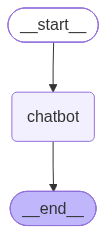

In [19]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

## graph 실행

In [20]:
result = graph.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Modular RAG를 설명해줘"
        }
    ]
})

## 결과 출력

In [21]:
display(
    Markdown(
        result["messages"][-1].content
    )
)

# Modular RAG (검색 증강 생성) 설명

## 📌 기본 개념

**Modular RAG**는 RAG 시스템을 독립적인 모듈로 분리하여 각 모듈을 유연하게 조합하고 최적화할 수 있는 아키텍처입니다.

---

## 🏗️ 핵심 모듈 구성

```
┌─────────────────────────────────────────┐
│         사용자 질문 (Query)              │
└────────────┬────────────────────────────┘
             │
    ┌────────▼────────┐
    │  1️⃣ 라우팅 모듈   │ ← 어떤 경로로 처리할지 결정
    └────────┬────────┘
             │
    ┌────────▼────────────────────┐
    │  2️⃣ 검색 모듈 (Retrieval)    │ ← 관련 문서 검색
    │  - 밀집 검색 (Dense)         │
    │  - 희소 검색 (Sparse)        │
    │  - 하이브리드 검색           │
    └────────┬────────────────────┘
             │
    ┌────────▼────────────────────┐
    │  3️⃣ 재순위 모듈 (Reranking)  │ ← 검색 결과 재정렬
    └────────┬────────────────────┘
             │
    ┌────────▼────────────────────┐
    │  4️⃣ 생성 모듈 (Generation)   │ ← 최종 답변 생성
    └────────┬────────────────────┘
             │
    ┌────────▼

# Local LLM과 함께 사용

uv add langchain-openai langchain-ollama

In [22]:
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama


MONO_BASE_URL = os.getenv("LLM_BASE_URL")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")


def get_llm(
    model: str,
    provider: str = "mono",
    temperature: float = 0,
    max_tokens: int = 512
):
    
    # ── MonoGPT / OpenAI-compatible API ──
    if provider == "mono":
        return ChatOpenAI(
            model=model,
            api_key=api_key,
            base_url=MONO_BASE_URL,
            temperature=temperature,
            use_responses_api=False,
            max_tokens=max_tokens,
        )

    # ── Ollama Local LLM ──
    elif provider == "ollama":
        return ChatOllama(
            model=model,
            base_url=OLLAMA_BASE_URL,
            temperature=temperature,
            num_predict=max_tokens,
        )

    else:
        raise ValueError(
            f"지원하지 않는 provider입니다: {provider}"
        )

## MonoGPT Claude 사용

In [23]:
llm = get_llm(
    model="claude-haiku-4.5",
    provider="mono"
)

response = llm.invoke(
    "Agentic RAG를 간단하게 설명해줘."
)

print(response.content)

# Agentic RAG 간단 설명

## 기본 개념
**Agentic RAG**는 AI 에이전트가 자율적으로 정보를 검색하고 판단하는 RAG(Retrieval-Augmented Generation) 방식입니다.

## 기존 RAG vs Agentic RAG

### 기존 RAG
```
질문 → 자동 검색 → 답변 생성
(정해진 절차대로만 진행)
```

### Agentic RAG
```
질문 → 에이전트가 판단 → 검색 필요? → 
검색 → 충분한가? → 추가 검색? → 답변 생성
(상황에 따라 유연하게 대응)
```

## 주요 특징

| 특징 | 설명 |
|------|------|
| **자율성** | 에이전트가 언제 검색할지 결정 |
| **반복성** | 필요하면 여러 번 검색 가능 |
| **판단력** | 정보가 충분한지 스스로 평가 |
| **도구 활용** | 검색, 계산, API 등 다양한 도구 사용 |

## 간단한 예시
- **기존**: "파리의 날씨는?" → 무조건 검색 → 답변
- **Agentic**: "파리의 날씨는?" → 최근 정보 필요한가? → 검색 → 충분한가? → 추가 검색 필요? → 답변

더 똑똑하고 효율적인 방식이라고 보면 됩니다! 🤖


## OpenAI GPT 

In [24]:
llm = get_llm(
    model="gpt-5.4",
    provider="mono"
)


response = llm.invoke(
    "Agentic RAG를 간단하게 설명해줘."
)

print(response.content)

Agentic RAG는 **기존 RAG(Retrieval-Augmented Generation)**에 **에이전트적 판단과 행동**이 추가된 방식입니다.

간단히 말하면:

- **기존 RAG**:  
  사용자의 질문이 들어오면  
  1. 관련 문서를 검색하고  
  2. 그 문서를 바탕으로 답변을 생성합니다.

- **Agentic RAG**:  
  여기에 더해 AI가 **스스로 판단**해서  
  - 무엇을 검색할지 정하고
  - 검색이 부족하면 다시 검색하고
  - 여러 소스의 정보를 비교하고
  - 필요하면 질문을 더 잘게 나누어 단계적으로 해결합니다.

즉, 단순히 “찾고 답하는” 수준을 넘어서,  
**“목표를 달성하기 위해 검색 전략을 조정하는 RAG”**라고 볼 수 있습니다.

### 예시
사용자 질문:  
“우리 회사가 일본 시장에 진출하려면 어떤 규제와 경쟁사를 검토해야 해?”

- **기본 RAG**: 관련 문서 몇 개 찾아서 요약
- **Agentic RAG**:  
  1. 질문을 “규제 조사”, “경쟁사 조사”, “시장 진입 전략”으로 나눔  
  2. 각각 따로 검색  
  3. 정보가 부족한 부분은 추가 검색  
  4. 결과를 종합해 더 구조적인 답변 생성

### 장점
- 복잡한 질문에 강함
- 검색 품질을 스스로 개선 가능
- 여러 단계 추론과 정보 통합에 유리

### 한 줄 정의
**Agentic RAG는 AI가 검색과 추론 과정을 능동적으로 계획·수정하면서 답을 만드는 RAG 방식입니다.**

원하면 제가 다음으로 **“RAG와 Agentic RAG의 구조 차이”**도 그림처럼 쉽게 설명해드릴게요.


## Ollama EXAONE 3.5 7.8B 사용

In [26]:
llm = get_llm(
    model="exaone3.5:latest",
    provider="ollama"
)

response = llm.invoke(
    "Agentic RAG를 간단하게 설명해줘."
)

print(response.content)

Agentive RAG는 **RAG 모델에 에이전트 기능을 추가한 것**입니다. 

* **RAG (Retrieval-Augmented Generation)**는 질문에 답하기 위해 **외부 지식 기반을 검색하고**, **생성 모델로 답변을 생성하는** 기술입니다. 
* **Agentive RAG**는 여기에 **목표 지향적인 행동**을 추가합니다. 즉, 단순히 정보를 제공하는 것을 넘어, **사용자의 의도를 이해하고 그에 따라 행동하는 에이전트처럼** 작동합니다.

**예시:**

* 일반 RAG는 "파리는 곤충이다"라는 질문에 답할 수 있습니다.
* Agentive RAG는 "오늘 저녁에 파리 요리를 만들어볼까?"라는 질문을 받으면, 레시피 검색, 재료 목록 제공, 조리 단계 안내 등 **다양한 행동**을 통해 사용자를 지원합니다.

핵심은 **RAG의 정보 제공 능력에 에이전트의 목표 지향적 행동을 결합**하여 더욱 **유용하고 상호 작용적인 경험**을 제공하는 것입니다.


# prefix 방식 
## langchain 사용

In [27]:
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama


MONO_BASE_URL = os.getenv("LLM_BASE_URL")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")


def get_llm(
    model: str,
    temperature: float = 0,
    max_tokens: int = 512
):
    
    provider, model_name = model.split("/", 1)

    if provider == "mono":

        return ChatOpenAI(
            model=model_name,
            api_key=api_key,
            base_url=MONO_BASE_URL,
            temperature=temperature,
            use_responses_api=False,
            max_tokens=max_tokens,
        )

    elif provider == "ollama":

        return ChatOllama(
            model=model_name,
            base_url=OLLAMA_BASE_URL,
            temperature=temperature,
            num_predict=max_tokens,
        )

    else:
        raise ValueError(
            f"지원하지 않는 provider: {provider}"
        )

In [28]:
claude = get_llm(
    "mono/claude-haiku-4.5"
)
response = claude.invoke(
    "Naive RAG란 무엇인가?"
)

print(response.content)

# Naive RAG란?

**Naive RAG(순진한 RAG)**는 가장 기본적인 형태의 검색 증강 생성(Retrieval-Augmented Generation) 시스템입니다.

## 기본 구조

```
질문 입력 → 문서 검색 → 관련 문서 선택 → LLM에 전달 → 답변 생성
```

## 주요 특징

### 1. **단순한 파이프라인**
- 사용자 질문을 임베딩으로 변환
- 벡터 데이터베이스에서 유사한 문서 검색
- 검색된 문서를 프롬프트에 포함시켜 LLM에 전달

### 2. **기본 구성 요소**
- 임베딩 모델
- 벡터 데이터베이스
- 대규모 언어 모델(LLM)

## 주요 문제점

| 문제 | 설명 |
|------|------|
| **검색 품질 저하** | 질문과 문서의 의미적 불일치 |
| **컨텍스트 손실** | 긴 문서에서 중요 정보 누락 |
| **순환 참조** | 관련성 낮은 문서 포함 |
| **확장성 제한** | 복잡한 질문에 대응 어려움 |

## 개선 방안

더 나은 RAG 시스템을 위해:
- **Advanced RAG**: 쿼리 최적화, 재순위화
- **Modular RAG**: 다양한 검색 전략 조합
- **Agent-based RAG**: 동적 검색 및 추론

Naive RAG는


In [29]:
gpt = get_llm(
    "mono/gpt-5.5"
)
response = gpt.invoke(
    "Naive RAG란 무엇인가?"
)

print(response.content)


In [30]:
exaone = get_llm(
    "ollama/exaone3.5:latest"
)

response = exaone.invoke(
    "Naive RAG란 무엇인가?"
)

print(response.content)

"Naive RAG"는 **RAG 모델의 간단하고 직관적인 버전**을 의미합니다. 

RAG (Retrieval-Augmented Generation)는 텍스트 생성 작업에서 정보 검색 능력을 강화하기 위해 설계된 모델입니다. 하지만 "Naive RAG"는 다음과 같은 특징을 가집니다:

* **단순한 정보 검색:** 복잡한 검색 알고리즘 대신 가장 가까운 문맥이나 관련 문서를 단순히 선택하는 방식을 사용합니다.
* **제한된 맥락 이해:**  입력 텍스트와 관련된 정보를 찾는 데 초점을 맞추지만, 맥락 이해나 복잡한 추론 능력은 제한적일 수 있습니다.
* **효율성 강조:**  계산 비용과 복잡성을 줄여 빠르고 쉽게 구현 가능하도록 설계되었습니다.

쉽게 말해, **"Naive RAG"는 RAG의 핵심 아이디어를 유지하면서도 구현을 단순화하여 접근성을 높인 버전**이라고 생각하면 됩니다. 

더 자세한 내용이나 특정 구현 예시가 필요하시면 알려주세요!


## LangGraph에서 사용

In [31]:
llm = get_llm(
    "ollama/exaone3.5:latest"
)

In [32]:
llm = get_llm(
    "mono/claude-haiku-4.5"
)

In [33]:
def chatbot(state):
    response = llm.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [34]:
builder = StateGraph(MessagesState)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

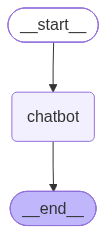

In [35]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)